Objective is to _"write some code simulating a poisson process"_

Starting here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html

A Poisson process models random events occurring in time (or space) where:
- Events occur independently
- The average rate of events is constant: 𝜆
- Number of events through time N(t)

Note that there is a difference between a Poisson process and a compound Poisson process

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fractions
import scipy
from matplotlib.collections import LineCollection
import jump_process # dans .py 
from scipy.stats import poisson

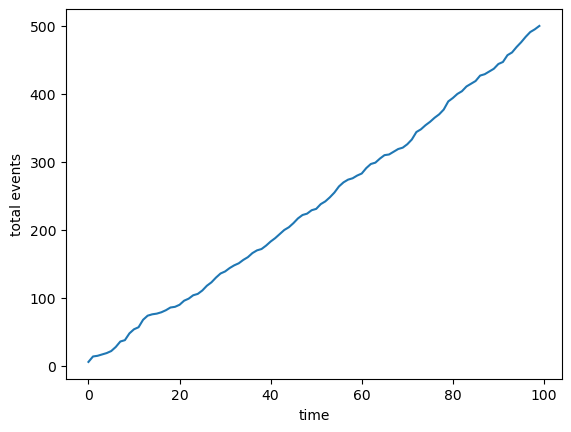

In [3]:
# rate 
lam = 5

# number of time intervals
T = 100

# simulate counts per interval
    #rvs(mu, loc=0, size=1, random_state=None)
events = poisson.rvs(mu=lam, size=T) # random variates 

# cumulative number of events
cumulative_events = np.cumsum(events)

plt.plot(cumulative_events)
plt.xlabel("time")
plt.ylabel("total events")
plt.show()

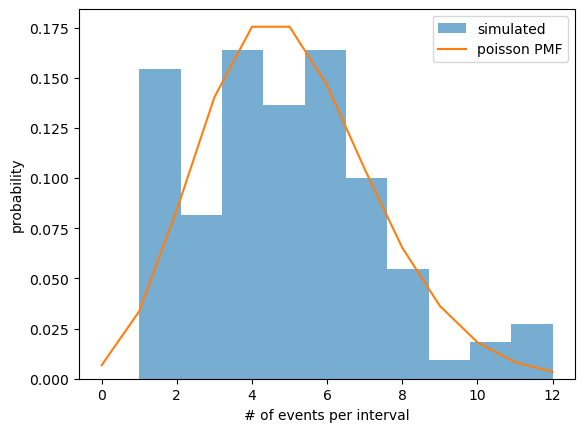

theoretical mean: 5.0
theoretical variance: 5.0
theoretical std: 2.23606797749979
theoretical median: 5.0


In [4]:
#looking at a probability mass function 
# possible event counts
k = np.arange(0, max(events)+1)

# theoretical PMF
pmf = poisson.pmf(k, mu=lam)

# histogram of simulated data
plt.hist(events, bins= 10, density=True, alpha=0.6, label="simulated")

# theoretical PMF
plt.plot(k, pmf, '-', label="poisson PMF")
plt.xlabel("# of events per interval")
plt.ylabel("probability")
plt.legend()
plt.show()

print("theoretical mean:", poisson.mean(mu=lam))
print("theoretical variance:", poisson.var(mu=lam))
print("theoretical std:", poisson.std(mu=lam))
print("theoretical median:", poisson.median(mu=lam))

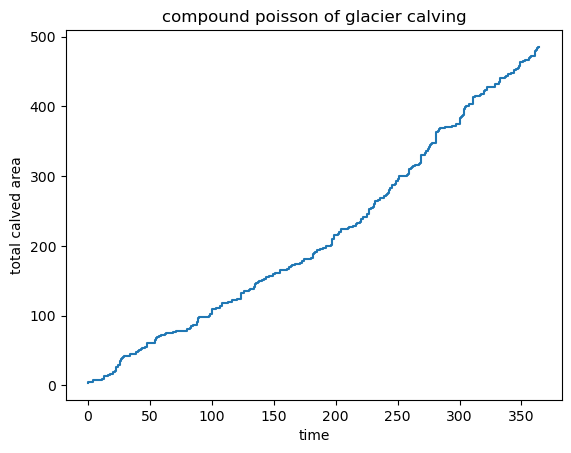

In [5]:
# so for glacial calving
#  if there is 1 event per day and we look at 365 days

L = 1 # event per day
T = 365 # days

# number of events 
N = np.random.poisson(L * T) #total number of calving events in a year

# event times - randomly distributed in the year
event_times = np.sort(np.random.uniform(0, T, N))

# glacier size
sizes = np.random.lognormal(mean=0, sigma=0.8, size = N)

# cumulative calved area
calved_area = np.cumsum(sizes)

plt.step(event_times, calved_area)
plt.xlabel("time")
plt.ylabel("total calved area")
plt.title("compound poisson of glacier calving")
plt.show()

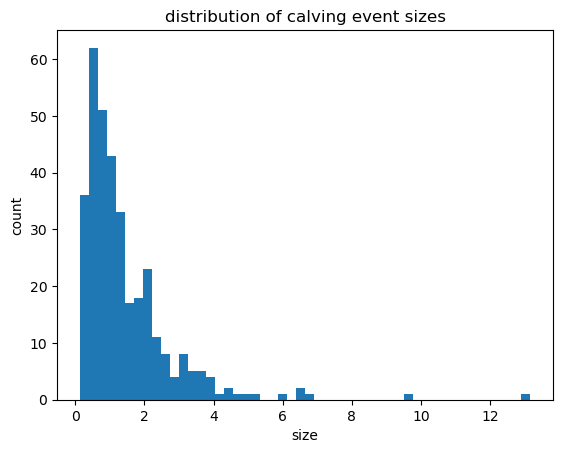

In [6]:
plt.hist(sizes, bins=50)
plt.xlabel("size")
plt.ylabel("count")
plt.title("distribution of calving event sizes")
plt.show()

In [7]:
calving_path = "/Users/sofiasuhinin/Desktop/GrIS_Calving/Jakobshavn-Isbrae-CalvingStatistics/jakobshavn_calving_ts.csv"
df = pd.read_csv(calving_path, parse_dates=["Date"])

df = df.sort_values("Date").reset_index(drop=True)
df = df.dropna(subset=["calving_magnitude"]).reset_index(drop=True)
df.head()

,Date,vel_final,dLdt,calving,calving_magnitude,dt_days,dt_years
0,2016-10-06,11866.819336,-16947.6000,28814.419336,78.889581,6.0,0.016427
1,2016-10-12,11866.819336,66055.4625,-54188.643164,-148.360419,6.0,0.016427
2,2016-10-18,11831.196289,-10969.6750,22800.871289,62.425383,6.0,0.016427
3,2016-10-24,11162.741211,-15961.4250,27124.166211,74.261920,6.0,0.016427
4,2016-10-30,11013.243164,-11870.6250,22883.868164,62.652616,6.0,0.016427


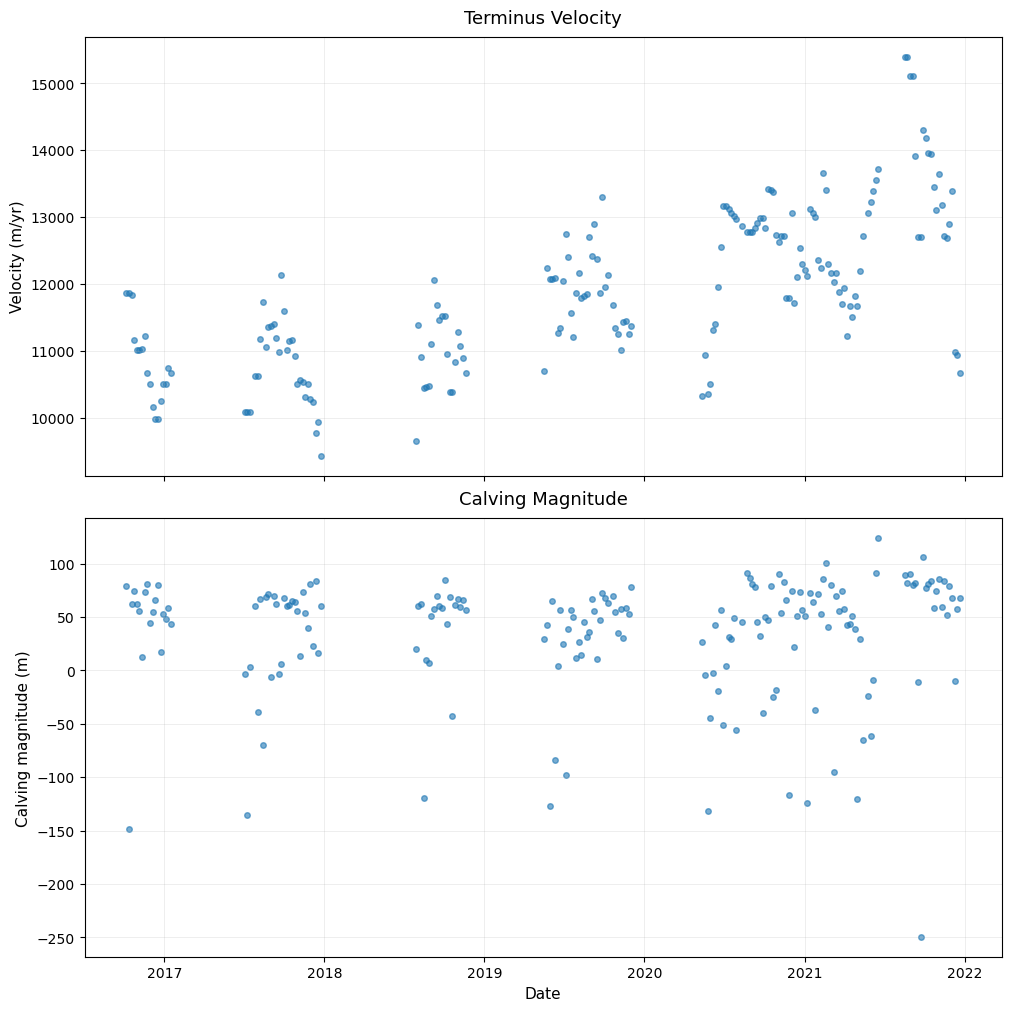

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True, constrained_layout=True)

#velocity
axes[0].scatter(df["Date"], df["vel_final"],s=16, alpha=0.6)
axes[0].set_ylabel("Velocity (m/yr)", fontsize=11)
axes[0].set_title("Terminus Velocity", fontsize=13, pad=10)

#calving mag
axes[1].scatter(df["Date"], df["calving_magnitude"],s=16, alpha=0.6)
axes[1].set_ylabel("Calving magnitude (m)", fontsize=11)
axes[1].set_xlabel("Date", fontsize=11)
axes[1].set_title("Calving Magnitude", fontsize=13, pad=10)

for ax in axes:
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.tick_params(axis="both", labelsize=10)

plt.show()

In [23]:
# attempt w/o glacier velocity stuff first
    # aim is to change event size and time in between events to create a synthetic data set that looks like mine

# generate rndm event times
    #time_scale is what i can change

def events_time(start_date, end_date, time_scale, seed=None):
    rng = np.random.default_rng(seed) #rndm number generator 

    current_time = start_date 
    event_times = []

    while current_time < end_date:
        wait = rng.exponential(scale=time_scale) #generates a waiting times from an exponential dist. 
        current_time += pd.Timedelta(days=wait) # move forward in time by that waiting time

        if current_time < end_date:
            event_times.append(current_time)  # store event time

    return pd.to_datetime(event_times)

# event_size generation 

def event_size(event_times, size_scale, seed = None):
    rng = np.random.default_rng(seed)

    size = rng.exponential(scale=size_scale, size = len(event_times))

    return pd.DataFrame({
        "Date": event_times,
        "size": size
    })  

# add to df. 
def events_to_df(df, events):
    df["synthetic_calving"] = 0.0 #set to 0 initially

    for i in range(len(df)-1):
        t_start = df.loc[i, "Date"]
        t_end = df.loc[i+1, "Date"]

        mask = (events["Date"] >= t_start) & (events["Date"] < t_end)
        df.loc[i, "synthetic_calving"] = events.loc[mask, "size"].sum()

    return df

In [33]:
#first run 
start = df["Date"].min() # start at first date df
end = df["Date"].max() # end at last date from df 

events = events_time(
    start_date=start,
    end_date=end,
    time_scale=6,
    seed=42
)

events_sizes = event_size(
    event_times=events,
    size_scale=23,
    seed=42
)

df_synthetic = events_to_df(df, events_sizes)

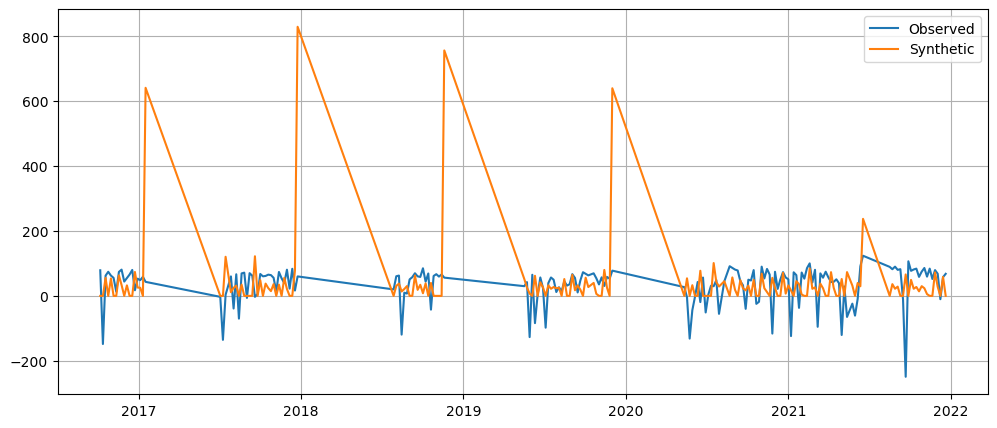

In [34]:
plt.figure(figsize=(12,5))
plt.plot(df_synthetic["Date"], df_synthetic["calving_magnitude"],  label="Observed")
plt.plot(df_synthetic["Date"], df_synthetic["synthetic_calving"],  label="Synthetic")
plt.legend()
plt.grid(True)
plt.show()